# Ablation: Number of Component Captions

Comparing different numbers of component captions per image:
- **N=1**: Single component caption
- **N=2 (Default)**: Two component captions (baseline)
- **N=3**: Three component captions
- **N=4**: Four component captions

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import numpy as np
from pathlib import Path

# Import shared ablation utilities
from ablation_utils import (
    setup_plotting_style,
    load_all_ablation_models,
    load_all_models_all_metrics,
    make_latex_ablation_table,
    plot_ablation_line,
    plot_ablation_bars,
    compute_deltas,
    print_summary,
    METRICS, METRIC_DISPLAY, METRIC_COLORS
)

# Set up plotting style
setup_plotting_style()

In [3]:
# =============================================================================
# CONFIGURATION - Define ablation models
# =============================================================================

ABLATION_MODELS = {
    "N=1": {
        "csv_path": "../evaluation/ablations/17-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_num_comp_captions_1.csv",
        "is_baseline": False,
        "description": "Single component caption",
        "num_captions": 1
    },
    "N=2 (Default)": {
        "csv_path": "../evaluation/exp_csv/19-Dec_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.0_inplace1.0_swap1.0_csclip-negclip-hard-new_cleaned.csv",
        "is_baseline": True,
        "description": "Two component captions (default)",
        "num_captions": 2
    },
    "N=3": {
        "csv_path": "../evaluation/ablations/17-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_num_comp_captions_3.csv",
        "is_baseline": False,
        "description": "Three component captions",
        "num_captions": 3
    },
    "N=4": {
        "csv_path": "../evaluation/ablations/17-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_num_comp_captions_4.csv",
        "is_baseline": False,
        "description": "Four component captions",
        "num_captions": 4
    },
}

# Primary metric for comparison
PRIMARY_METRIC = "text_contrastive_accuracy"

# Checkpoint selection (use best or specific step)
CHECKPOINT_STEP = None  # None = use best checkpoint, or specify step like 5000

# Ablation metadata
ABLATION_NAME = "NUMBER OF COMPONENT CAPTIONS ABLATION"
PARAM_KEY = "num_captions"
PARAM_LABEL = r'Number of Component Captions (N)'

print("Ablation: Number of Component Captions (N)")
print("="*50)
for name, cfg in ABLATION_MODELS.items():
    baseline_mark = " [BASELINE]" if cfg["is_baseline"] else ""
    print(f"  {name}{baseline_mark}: {cfg['description']}")

Ablation: Number of Component Captions (N)
  N=1: Single component caption
  N=2 (Default) [BASELINE]: Two component captions (default)
  N=3: Three component captions
  N=4: Four component captions


In [4]:
# =============================================================================
# LOAD DATA - Single Metric (Primary)
# =============================================================================

scores_df = load_all_ablation_models(ABLATION_MODELS, PRIMARY_METRIC, CHECKPOINT_STEP)
print(f"\nLoaded {len(scores_df)} models, {len(scores_df.columns)} datasets")

Loading N=1...
[apply_mappings] Dropped 5 original rows replaced by aliased metrics
  Loaded 65 datasets (step=20000)
Loading N=2 (Default)...
  Loaded 65 datasets (step=15000)
Loading N=3...
[apply_mappings] Dropped 5 original rows replaced by aliased metrics
  Loaded 65 datasets (step=15000)
Loading N=4...
[apply_mappings] Dropped 308 original rows replaced by aliased metrics
  Loaded 65 datasets (step=20000)

Common datasets (65): ['VL_CheckList/rel_spatial', 'ColorFoil', 'VL_CheckList/attr_state', 'VL_CheckList/obj_size', 'VL_CheckList/rel_action', 'VL_CheckList/attr_size', 'VL_CheckList/attr_material', 'VL_CheckList/attr_action', 'VL_CheckList/attr_color', 'VL_CheckList/obj_location', 'MMVP/Text', 'MMVP/Camera Perspective', 'ControlledImages/VG-Two', 'MMVP/Spatial', 'SugarCrepe/replace_obj', 'SugarCrepe++/swap_object', 'VALSE/actions', 'SPEC/absolute_size', 'ControlledImages/B', 'VALSE/relations', 'SPEC/relative_size', 'ColorSwap', 'SugarCrepe/replace_att', 'ControlledImages/COCO-

In [5]:
# =============================================================================
# DISPLAY RAW SCORES TABLE
# =============================================================================

# Convert to percentage and display
scores_pct = scores_df * 100

# Add average column
scores_pct['Average'] = scores_pct.mean(axis=1)

print("\n" + "="*60)
print(f"ABLATION: NUMBER OF COMPONENT CAPTIONS (N)")
print(f"Metric: {PRIMARY_METRIC}")
print("="*60)
display(scores_pct.round(1).style.highlight_max(axis=0, color='lightgreen'))


ABLATION: NUMBER OF COMPONENT CAPTIONS (N)
Metric: text_contrastive_accuracy


,VL_CheckList/rel_spatial,ColorFoil,VL_CheckList/attr_state,VL_CheckList/obj_size,VL_CheckList/rel_action,VL_CheckList/attr_size,VL_CheckList/attr_material,VL_CheckList/attr_action,VL_CheckList/attr_color,VL_CheckList/obj_location,MMVP/Text,MMVP/Camera Perspective,ControlledImages/VG-Two,MMVP/Spatial,SugarCrepe/replace_obj,SugarCrepe++/swap_object,VALSE/actions,SPEC/absolute_size,ControlledImages/B,VALSE/relations,SPEC/relative_size,ColorSwap,SugarCrepe/replace_att,ControlledImages/COCO-One,MMVP/Structural Character,SPEC/existence,ControlledImages/VG-One,SugarCrepe/swap_att,VALSE/noun phrases,SugarCrepe++/replace_object,MMVP/State,ControlledImages/COCO-Two,SugarCrepe/replace_rel,SugarCrepe++/swap_atribute,VALSE/coreference,SPEC/absolute_spatial,MMVP/Color,VALSE/existence,COLA/multi_objects,BLA/co,NegBench/VOC2007_mcq_llama3.1_rephrased,COCO-CF,VG_Attribution,SugarCrepe++/replace_relation,MMVP/Orientation,VisMin,BLA/ap,NegBench/msr_vtt_mcq_rephrased_llama,SugarCrepe/swap_obj,SugarCrepe++/replace_attribute,MMVP/Quantity,MMVP/Presence,SPEC/relative_spatial,VALSE/counting,Flickr30k_Order,NegBench/COCO_val_mcq_llama3.1_rephrased,ControlledImages/A,SugarCrepe/add_obj,VALSE/plurals,SPEC/count,BLA/rc,COCO_Order,Winoground,VG_Relation,SugarCrepe/add_att,Average
Model,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
N=1,80.900000,90.200000,63.700000,93.300000,82.800000,63.000000,73.200000,78.300000,79.600000,94.200000,6.700000,13.300000,51.200000,26.700000,94.600000,50.200000,83.500000,40.600000,32.400000,69.200000,31.500000,58.300000,87.600000,46.300000,13.300000,69.900000,46.700000,74.900000,94.500000,91.300000,6.700000,51.400000,80.200000,58.000000,58.000000,12.100000,6.700000,84.600000,34.800000,48.600000,37.000000,77.600000,69.900000,62.400000,26.700000,78.100000,52.600000,30.400000,70.200000,75.400000,13.300000,13.300000,29.700000,66.900000,96.700000,30.900000,31.100000,90.200000,72.400000,36.100000,49.200000,95.800000,28.500000,59.600000,82.900000,56.900000
N=2 (Default),80.700000,90.500000,65.200000,93.100000,83.000000,64.300000,74.500000,78.100000,79.200000,94.100000,13.300000,6.700000,53.100000,46.700000,94.900000,52.200000,83.200000,38.800000,34.600000,70.100000,32.700000,59.000000,86.200000,48.000000,6.700000,68.700000,45.100000,74.500000,93.700000,91.700000,13.300000,50.900000,79.700000,56.500000,56.200000,12.200000,13.300000,83.400000,41.000000,48.400000,37.800000,78.200000,70.000000,62.400000,13.300000,78.600000,52.700000,29.200000,69.000000,74.200000,6.700000,0.000000,29.500000,66.500000,96.700000,31.400000,29.100000,90.800000,70.500000,34.500000,49.600000,95.300000,29.800000,59.500000,80.800000,56.800000
N=3,78.000000,89.500000,64.900000,93.200000,82.600000,64.300000,73.700000,78.200000,79.200000,94.100000,6.700000,13.300000,50.400000,26.700000,94.900000,51.400000,84.900000,38.100000,35.500000,68.800000,32.300000,59.300000,87.400000,50.700000,6.700000,67.900000,43.500000,75.400000,93.200000,91.100000,20.000000,50.500000,80.900000,56.200000,56.300000,12.600000,13.300000,85.300000,35.200000,49.200000,37.800000,78.000000,69.700000,64.100000,6.700000,78.500000,50.100000,31.600000,73.100000,74.000000,6.700000,20.000000,29.100000,66.100000,96.900000,33.300000,29.400000,90.500000,71.400000,35.100000,48.900000,94.800000,28.000000,59.500000,81.200000,56.800000
N=4,80.800000,89.500000,64.100000,93.300000,82.400000,64.400000,73.900000,77.800000,79.600000,94.200000,13.300000,0.000000,51.900000,20.000000,94.400000,49.800000,83.300000,40.600000,36.500000,71.400000,31.800000,60.300000,88.100000,47.400000,13.300000,69.400000,45.900000,74.900000,93.300000,91.500000,0.000000,51.600000,79.200000,58.400000,57.600000,12.300000,13.300000,84.400000,38.100000,49.600000,38.000000,77.600000,70.300000,63.700000,26.700000,78.100000,52.000000,31.000000,70.200000,74.500000,13.300000,6.700000,28.700000,66.500000,96.600000,31.900000,32.000000,89.100000,70.700000,34.400000,47.900000,94.900000,28.500000,59.500000,82.200000,56.700000


In [6]:
# =============================================================================
# LOAD ALL METRICS (Text, Image, Group Contrastive Accuracy)
# =============================================================================

# Load all models with all metrics
all_metrics_df = load_all_models_all_metrics(ABLATION_MODELS, METRICS, CHECKPOINT_STEP)

# Extract just the summary columns (I2T, T2I, Group)
summary_cols = [col for col in ['I2T', 'T2I', 'Group'] if col in all_metrics_df.columns]
summary_df = all_metrics_df[summary_cols].copy()

# Add overall average
summary_df['Average'] = summary_df.mean(axis=1)

print("\n" + "="*60)
print("ABLATION: NUMBER OF COMPONENT CAPTIONS - ALL METRICS")
print("="*60)
display((summary_df * 100).round(1).style.highlight_max(axis=0, color='lightgreen'))

Loading N=1...
[apply_mappings] Dropped 5 original rows replaced by aliased metrics
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading N=2 (Default)...
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading N=3...
[apply_mappings] Dropped 5 original rows replaced by aliased metrics
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading N=4...
[apply_mappings] Dropped 308 original rows replaced by aliased metrics
  Loaded metrics: ['I2T', 'T2I', 'Group']

Common datasets across all models (19): ['BLA', 'COCO-CF', 'COCO_Order', 'COLA', 'ColorFoil', 'ColorSwap', 'ControlledImages', 'Flickr30k_Order', 'MMVP', 'NegBench', 'SPEC', 'SugarCrepe', 'SugarCrepe++', 'VALSE', 'VG_Attribution', 'VG_Relation', 'VL_CheckList', 'VisMin', 'Winoground']

ABLATION: NUMBER OF COMPONENT CAPTIONS - ALL METRICS


,I2T,T2I,Group,Average
Model,,,,
N=1,61.600000,40.900000,24.900000,42.500000
N=2 (Default),62.000000,41.600000,25.400000,43.000000
N=3,61.600000,40.500000,24.900000,42.300000
N=4,61.800000,40.800000,24.700000,42.400000


In [7]:
# =============================================================================
# LATEX TABLE GENERATION
# =============================================================================

# Generate LaTeX table
latex_table = make_latex_ablation_table(
    summary_df,
    ABLATION_MODELS,
    caption="Number of component captions (N) ablation. I2T = Image-to-Text, T2I = Text-to-Image, Group = both correct. Best in \\textbf{bold}, baseline \\underline{underlined}.",
    label="tab:ablation_num_comp_captions",
)

print("="*60)
print("LATEX TABLE")
print("="*60)
print(latex_table)

LATEX TABLE
\begin{table}[t]
  \centering
  \small
  \caption{Number of component captions (N) ablation. I2T = Image-to-Text, T2I = Text-to-Image, Group = both correct. Best in \textbf{bold}, baseline \underline{underlined}.}
  \label{tab:ablation_num_comp_captions}
  \begin{tabular}{lcccc}
    \toprule
    Model & I2T & T2I & Group & Average \\
    \midrule
    N=1 & 61.6 & 40.9 & 24.9 & 42.5 \\
    N=2 (Default) & \textbf{\underline{62.0}} & \textbf{\underline{41.6}} & \textbf{\underline{25.4}} & \textbf{\underline{43.0}} \\
    N=3 & 61.6 & 40.5 & 24.9 & 42.3 \\
    N=4 & 61.8 & 40.8 & 24.7 & 42.4 \\
    \bottomrule
  \end{tabular}
\end{table}


In [8]:
# =============================================================================
# VISUALIZATION: LINE PLOT (N vs Performance)
# =============================================================================

# Extract N values and corresponding scores
n_values = [ABLATION_MODELS[model]['num_captions'] for model in summary_df.index]

fig, ax = plot_ablation_line(
    summary_df,
    n_values,
    ABLATION_MODELS,
    param_label=PARAM_LABEL,
    title='Number of Component Captions Ablation',
    save_path='../paper_figures/ablation_num_comp_captions_line.pdf'
)

TypeError: list indices must be integers or slices, not str

Saved: ../paper_figures/ablation_num_comp_captions_bars.pdf


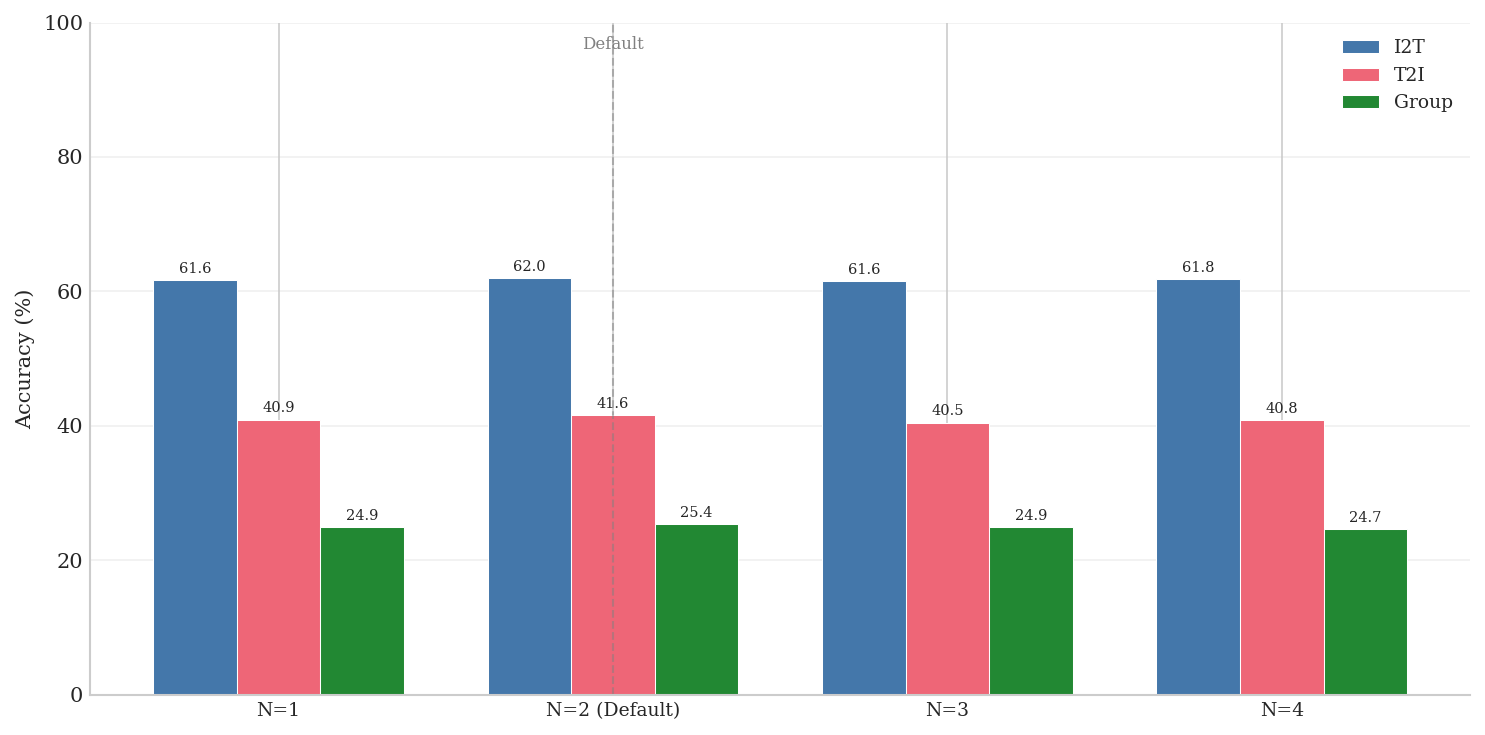

In [9]:
# =============================================================================
# VISUALIZATION: GROUPED BAR CHART (All Metrics)
# =============================================================================

fig, ax = plot_ablation_bars(
    summary_df,
    ABLATION_MODELS,
    title='Number of Component Captions Ablation',
    save_path='../paper_figures/ablation_num_comp_captions_bars.pdf'
)

In [10]:
# =============================================================================
# COMPUTE DELTAS FROM BASELINE
# =============================================================================

deltas_df = compute_deltas(summary_df, ABLATION_MODELS)

print("\n" + "="*60)
print("DELTA FROM BASELINE (percentage points)")
print("="*60)
display(deltas_df.round(2).style.background_gradient(cmap='RdYlGn', axis=None))


DELTA FROM BASELINE (percentage points)


,I2T,T2I,Group,Average
Model,,,,
N=1,-0.370000,-0.630000,-0.500000,-0.500000
N=2 (Default),0.000000,0.000000,0.000000,0.000000
N=3,-0.420000,-1.070000,-0.490000,-0.660000
N=4,-0.230000,-0.740000,-0.750000,-0.580000


In [11]:
# =============================================================================
# SUMMARY
# =============================================================================

print_summary(summary_df, ABLATION_MODELS, ABLATION_NAME, PARAM_KEY)


SUMMARY: NUMBER OF COMPONENT CAPTIONS ABLATION

Baseline: N=2 (Default)

Average Performance:
    N=1: 42.5% (-0.50pp vs baseline) | num_captions=1
  ★ N=2 (Default): 43.0% (+0.00pp vs baseline) | num_captions=2
    N=3: 42.3% (-0.66pp vs baseline) | num_captions=3
    N=4: 42.4% (-0.58pp vs baseline) | num_captions=4

Key Findings:
  - Best: N=2 (Default) (43.0%)
  - Worst: N=3 (42.3%)
  - Gap: 0.7pp


In [12]:
# =============================================================================
# DATASET-WISE AND SUBSET-WISE TABLES (with ARO merging)
# =============================================================================

from ablation_utils import (
    load_all_models_per_dataset,
    load_all_models_per_subset,
    make_latex_dataset_table,
    get_datasets_and_subsets,
    display_all_tables,
    load_benchmark_config
)

# Load benchmark config for dataset merge rules (e.g., ARO)
bench_cfg = load_benchmark_config()

# Display all tables for the primary metric (I2T) with ARO merging
dataset_df, subset_df, datasets_subsets = display_all_tables(
    ABLATION_MODELS, PRIMARY_METRIC, CHECKPOINT_STEP, 
    show_latex=True, apply_merge=True, benchmark_config=bench_cfg
)


PER-DATASET RESULTS (I2T)
[apply_mappings] Dropped 5 original rows replaced by aliased metrics
[apply_mappings] Dropped 5 original rows replaced by aliased metrics
[apply_mappings] Dropped 308 original rows replaced by aliased metrics


,ARO,BLA,COCO-CF,COLA,ColorFoil,ColorSwap,ControlledImages,MMVP,NegBench,SPEC,SugarCrepe,SugarCrepe++,VALSE,VL_CheckList,VisMin,Winoground,Average
Model,,,,,,,,,,,,,,,,,
N=1,80.500000,50.100000,77.600000,34.800000,90.200000,58.300000,43.200000,14.100000,32.800000,36.600000,82.900000,67.400000,75.600000,78.800000,78.100000,28.500000,58.100000
N=2 (Default),80.400000,50.200000,78.200000,41.000000,90.500000,59.000000,43.500000,13.300000,32.800000,36.100000,82.200000,67.400000,74.800000,79.200000,78.600000,29.800000,58.600000
N=3,80.200000,49.400000,78.000000,35.200000,89.500000,59.300000,43.300000,13.300000,34.200000,35.900000,83.300000,67.400000,75.200000,78.700000,78.500000,28.000000,58.100000
N=4,80.300000,49.900000,77.600000,38.100000,89.500000,60.300000,44.200000,11.900000,33.600000,36.200000,82.600000,67.600000,75.300000,78.900000,78.100000,28.500000,58.300000



LaTeX:
\begin{table}[t]
  \centering
  \scriptsize
  \caption{Per-dataset I2T accuracy.}
  \label{tab:ablation_datasets_i2t}
  \begin{adjustbox}{max width=\textwidth}
  \begin{tabular}{lccccccccccccccccc}
    \toprule
    Model & \rotatebox{60}{ARO} & \rotatebox{60}{BLA} & \rotatebox{60}{COCO-CF} & \rotatebox{60}{COLA} & \rotatebox{60}{ColorFoil} & \rotatebox{60}{ColorSwap} & \rotatebox{60}{ControlledImages} & \rotatebox{60}{MMVP} & \rotatebox{60}{NegBench} & \rotatebox{60}{SPEC} & \rotatebox{60}{SugarCrepe} & \rotatebox{60}{SugarCrepe++} & \rotatebox{60}{VALSE} & \rotatebox{60}{VL\_CheckList} & \rotatebox{60}{VisMin} & \rotatebox{60}{Winoground} & \rotatebox{60}{Avg} \\
    \midrule
    N=1 & \textbf{80.5} & 50.1 & 77.6 & 34.8 & 90.2 & 58.3 & 43.2 & \textbf{14.1} & 32.8 & \textbf{36.6} & 82.9 & 67.4 & \textbf{75.6} & 78.8 & 78.1 & 28.5 & 58.1 \\
    N=2 (Default) & \underline{80.4} & \textbf{\underline{50.2}} & \textbf{\underline{78.2}} & \textbf{\underline{41.0}} & \textbf{\underlin

,VL_CheckList/rel_spatial,ColorFoil,VL_CheckList/attr_state,VL_CheckList/obj_size,VL_CheckList/rel_action,VL_CheckList/attr_size,VL_CheckList/attr_material,VL_CheckList/attr_action,VL_CheckList/attr_color,VL_CheckList/obj_location,MMVP/Text,MMVP/Camera Perspective,ControlledImages/VG-Two,MMVP/Spatial,SugarCrepe/replace_obj,SugarCrepe++/swap_object,VALSE/actions,SPEC/absolute_size,ControlledImages/B,VALSE/relations,SPEC/relative_size,ColorSwap,SugarCrepe/replace_att,ControlledImages/COCO-One,MMVP/Structural Character,SPEC/existence,ControlledImages/VG-One,SugarCrepe/swap_att,VALSE/noun phrases,SugarCrepe++/replace_object,MMVP/State,ControlledImages/COCO-Two,SugarCrepe/replace_rel,SugarCrepe++/swap_atribute,VALSE/coreference,SPEC/absolute_spatial,MMVP/Color,VALSE/existence,COLA/multi_objects,BLA/co,NegBench/VOC2007_mcq_llama3.1_rephrased,COCO-CF,ARO/VG_Attribution,SugarCrepe++/replace_relation,MMVP/Orientation,VisMin,BLA/ap,NegBench/msr_vtt_mcq_rephrased_llama,SugarCrepe/swap_obj,SugarCrepe++/replace_attribute,MMVP/Quantity,MMVP/Presence,SPEC/relative_spatial,VALSE/counting,ARO/Flickr30k_Order,NegBench/COCO_val_mcq_llama3.1_rephrased,ControlledImages/A,SugarCrepe/add_obj,VALSE/plurals,SPEC/count,BLA/rc,ARO/COCO_Order,Winoground,ARO/VG_Relation,SugarCrepe/add_att,Average
Model,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
N=1,80.900000,90.200000,63.700000,93.300000,82.800000,63.000000,73.200000,78.300000,79.600000,94.200000,6.700000,13.300000,51.200000,26.700000,94.600000,50.200000,83.500000,40.600000,32.400000,69.200000,31.500000,58.300000,87.600000,46.300000,13.300000,69.900000,46.700000,74.900000,94.500000,91.300000,6.700000,51.400000,80.200000,58.000000,58.000000,12.100000,6.700000,84.600000,34.800000,48.600000,37.000000,77.600000,69.900000,62.400000,26.700000,78.100000,52.600000,30.400000,70.200000,75.400000,13.300000,13.300000,29.700000,66.900000,96.700000,30.900000,31.100000,90.200000,72.400000,36.100000,49.200000,95.800000,28.500000,59.600000,82.900000,56.900000
N=2 (Default),80.700000,90.500000,65.200000,93.100000,83.000000,64.300000,74.500000,78.100000,79.200000,94.100000,13.300000,6.700000,53.100000,46.700000,94.900000,52.200000,83.200000,38.800000,34.600000,70.100000,32.700000,59.000000,86.200000,48.000000,6.700000,68.700000,45.100000,74.500000,93.700000,91.700000,13.300000,50.900000,79.700000,56.500000,56.200000,12.200000,13.300000,83.400000,41.000000,48.400000,37.800000,78.200000,70.000000,62.400000,13.300000,78.600000,52.700000,29.200000,69.000000,74.200000,6.700000,0.000000,29.500000,66.500000,96.700000,31.400000,29.100000,90.800000,70.500000,34.500000,49.600000,95.300000,29.800000,59.500000,80.800000,56.800000
N=3,78.000000,89.500000,64.900000,93.200000,82.600000,64.300000,73.700000,78.200000,79.200000,94.100000,6.700000,13.300000,50.400000,26.700000,94.900000,51.400000,84.900000,38.100000,35.500000,68.800000,32.300000,59.300000,87.400000,50.700000,6.700000,67.900000,43.500000,75.400000,93.200000,91.100000,20.000000,50.500000,80.900000,56.200000,56.300000,12.600000,13.300000,85.300000,35.200000,49.200000,37.800000,78.000000,69.700000,64.100000,6.700000,78.500000,50.100000,31.600000,73.100000,74.000000,6.700000,20.000000,29.100000,66.100000,96.900000,33.300000,29.400000,90.500000,71.400000,35.100000,48.900000,94.800000,28.000000,59.500000,81.200000,56.800000
N=4,80.800000,89.500000,64.100000,93.300000,82.400000,64.400000,73.900000,77.800000,79.600000,94.200000,13.300000,0.000000,51.900000,20.000000,94.400000,49.800000,83.300000,40.600000,36.500000,71.400000,31.800000,60.300000,88.100000,47.400000,13.300000,69.400000,45.900000,74.900000,93.300000,91.500000,0.000000,51.600000,79.200000,58.400000,57.600000,12.300000,13.300000,84.400000,38.100000,49.600000,38.000000,77.600000,70.300000,63.700000,26.700000,78.100000,52.000000,31.000000,70.200000,74.500000,13.300000,6.700000,28.700000,66.500000,96.600000,31.900000,32.000000,89.100000,70.700000,34.400000,47.900000,94.900000,28.500000,59.500000,82.2000


LaTeX:
\begin{table}[t]
  \centering
  \scriptsize
  \caption{Per-subset I2T accuracy.}
  \label{tab:ablation_subsets_i2t}
  \begin{adjustbox}{max width=\textwidth}
  \begin{tabular}{lcccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccc}
    \toprule
    Model & \rotatebox{60}{VL\_CheckList/rel\_spatial} & \rotatebox{60}{ColorFoil} & \rotatebox{60}{VL\_CheckList/attr\_state} & \rotatebox{60}{VL\_CheckList/obj\_size} & \rotatebox{60}{VL\_CheckList/rel\_action} & \rotatebox{60}{VL\_CheckList/attr\_size} & \rotatebox{60}{VL\_CheckList/attr\_material} & \rotatebox{60}{VL\_CheckList/attr\_action} & \rotatebox{60}{VL\_CheckList/attr\_color} & \rotatebox{60}{VL\_CheckList/obj\_location} & \rotatebox{60}{MMVP/Text} & \rotatebox{60}{MMVP/Camera Perspective} & \rotatebox{60}{ControlledImages/VG-Two} & \rotatebox{60}{MMVP/Spatial} & \rotatebox{60}{SugarCrepe/replace\_obj} & \rotatebox{60}{SugarCrepe++/swap\_object} & \rotatebox{60}{VALSE/actions} & \rotatebox{60}{SPEC/absolute\_siz

In [13]:
# =============================================================================
# PER-DATASET LATEX TABLE (for specific datasets with subsets)
# =============================================================================

# Generate separate tables for datasets with multiple subsets
for dataset_name, subsets in sorted(datasets_subsets.items()):
    if len(subsets) > 1:  # Only show datasets with multiple subsets
        print(f"\n{'='*60}")
        print(f"DATASET: {dataset_name} (subsets: {subsets})")
        print("="*60)
        
        # Filter subset_df to only this dataset
        cols = [c for c in subset_df.columns if c.startswith(f"{dataset_name}/") or c == dataset_name]
        if cols:
            ds_df = subset_df[cols]
            ds_pct = ds_df * 100
            ds_pct['Avg'] = ds_pct.mean(axis=1)
            display(ds_pct.round(1).style.highlight_max(axis=0, color='lightgreen'))
            
            # LaTeX
            print("\nLaTeX:")
            print(make_latex_dataset_table(
                ds_df, ABLATION_MODELS,
                caption=f"{dataset_name} subset breakdown (I2T accuracy).",
                label=f"tab:ablation_{dataset_name.lower()}_subsets",
                rotate_headers=False
            ))


DATASET: ARO (subsets: ['COCO_Order', 'Flickr30k_Order', 'VG_Attribution', 'VG_Relation'])


,ARO/VG_Attribution,ARO/Flickr30k_Order,ARO/COCO_Order,ARO/VG_Relation,Avg
Model,,,,,
N=1,69.900000,96.700000,95.800000,59.600000,80.500000
N=2 (Default),70.000000,96.700000,95.300000,59.500000,80.400000
N=3,69.700000,96.900000,94.800000,59.500000,80.200000
N=4,70.300000,96.600000,94.900000,59.500000,80.300000



LaTeX:
\begin{table}[t]
  \centering
  \scriptsize
  \caption{ARO subset breakdown (I2T accuracy).}
  \label{tab:ablation_aro_subsets}
  \begin{adjustbox}{max width=\textwidth}
  \begin{tabular}{lccccc}
    \toprule
    Model & ARO/VG\_Attribution & ARO/Flickr30k\_Order & ARO/COCO\_Order & ARO/VG\_Relation & Avg \\
    \midrule
    N=1 & 69.9 & 96.7 & \textbf{95.8} & \textbf{59.6} & \textbf{80.5} \\
    N=2 (Default) & \underline{70.0} & \underline{96.7} & \underline{95.3} & \underline{59.5} & \underline{80.4} \\
    N=3 & 69.7 & \textbf{96.9} & 94.8 & 59.5 & 80.2 \\
    N=4 & \textbf{70.3} & 96.6 & 94.9 & 59.5 & 80.3 \\
    \bottomrule
  \end{tabular}
  \end{adjustbox}
\end{table}

DATASET: BLA (subsets: ['ap', 'co', 'rc'])


,BLA/co,BLA/ap,BLA/rc,Avg
Model,,,,
N=1,48.600000,52.600000,49.200000,50.100000
N=2 (Default),48.400000,52.700000,49.600000,50.200000
N=3,49.200000,50.100000,48.900000,49.400000
N=4,49.600000,52.000000,47.900000,49.900000



LaTeX:
\begin{table}[t]
  \centering
  \scriptsize
  \caption{BLA subset breakdown (I2T accuracy).}
  \label{tab:ablation_bla_subsets}
  \begin{adjustbox}{max width=\textwidth}
  \begin{tabular}{lcccc}
    \toprule
    Model & BLA/co & BLA/ap & BLA/rc & Avg \\
    \midrule
    N=1 & 48.6 & 52.6 & 49.2 & 50.1 \\
    N=2 (Default) & \underline{48.4} & \textbf{\underline{52.7}} & \textbf{\underline{49.6}} & \textbf{\underline{50.2}} \\
    N=3 & 49.2 & 50.1 & 48.9 & 49.4 \\
    N=4 & \textbf{49.6} & 52.0 & 47.9 & 49.9 \\
    \bottomrule
  \end{tabular}
  \end{adjustbox}
\end{table}

DATASET: ControlledImages (subsets: ['A', 'B', 'COCO-One', 'COCO-Two', 'VG-One', 'VG-Two'])


...


LaTeX:
\begin{table}[t]
  \centering
  \scriptsize
  \caption{SugarCrepe++ subset breakdown (I2T accuracy).}
  \label{tab:ablation_sugarcrepe++_subsets}
  \begin{adjustbox}{max width=\textwidth}
  \begin{tabular}{lcccccc}
    \toprule
    Model & SugarCrepe++/swap\_object & SugarCrepe++/replace\_object & SugarCrepe++/swap\_atribute & SugarCrepe++/replace\_relation & SugarCrepe++/replace\_attribute & Avg \\
    \midrule
    N=1 & 50.2 & 91.3 & 58.0 & 62.4 & \textbf{75.4} & 67.4 \\
    N=2 (Default) & \textbf{\underline{52.2}} & \textbf{\underline{91.7}} & \underline{56.5} & \underline{62.4} & \underline{74.2} & \underline{67.4} \\
    N=3 & 51.4 & 91.1 & 56.2 & \textbf{64.1} & 74.0 & 67.4 \\
    N=4 & 49.8 & 91.5 & \textbf{58.4} & 63.7 & 74.5 & \textbf{67.6} \\
    \bottomrule
  \end{tabular}
  \end{adjustbox}
\end{table}

DATASET: VALSE (subsets: ['actions', 'coreference', 'counting', 'existence', 'noun phrases', 'plurals', 'relations'])


,VALSE/actions,VALSE/relations,VALSE/noun phrases,VALSE/coreference,VALSE/existence,VALSE/counting,VALSE/plurals,Avg
Model,,,,,,,,
N=1,83.500000,69.200000,94.500000,58.000000,84.600000,66.900000,72.400000,75.600000
N=2 (Default),83.200000,70.100000,93.700000,56.200000,83.400000,66.500000,70.500000,74.800000
N=3,84.900000,68.800000,93.200000,56.300000,85.300000,66.100000,71.400000,75.200000
N=4,83.300000,71.400000,93.300000,57.600000,84.400000,66.500000,70.700000,75.300000



LaTeX:
\begin{table}[t]
  \centering
  \scriptsize
  \caption{VALSE subset breakdown (I2T accuracy).}
  \label{tab:ablation_valse_subsets}
  \begin{adjustbox}{max width=\textwidth}
  \begin{tabular}{lcccccccc}
    \toprule
    Model & VALSE/actions & VALSE/relations & VALSE/noun phrases & VALSE/coreference & VALSE/existence & VALSE/counting & VALSE/plurals & Avg \\
    \midrule
    N=1 & 83.5 & 69.2 & \textbf{94.5} & \textbf{58.0} & 84.6 & \textbf{66.9} & \textbf{72.4} & \textbf{75.6} \\
    N=2 (Default) & \underline{83.2} & \underline{70.1} & \underline{93.7} & \underline{56.2} & \underline{83.4} & \underline{66.5} & \underline{70.5} & \underline{74.8} \\
    N=3 & \textbf{84.9} & 68.8 & 93.2 & 56.3 & \textbf{85.3} & 66.1 & 71.4 & 75.2 \\
    N=4 & 83.3 & \textbf{71.4} & 93.3 & 57.6 & 84.4 & 66.5 & 70.7 & 75.3 \\
    \bottomrule
  \end{tabular}
  \end{adjustbox}
\end{table}

DATASET: VL_CheckList (subsets: ['attr_action', 'attr_color', 'attr_material', 'attr_size', 'attr_state', 'ob

,VL_CheckList/rel_spatial,VL_CheckList/attr_state,VL_CheckList/obj_size,VL_CheckList/rel_action,VL_CheckList/attr_size,VL_CheckList/attr_material,VL_CheckList/attr_action,VL_CheckList/attr_color,VL_CheckList/obj_location,Avg
Model,,,,,,,,,,
N=1,80.900000,63.700000,93.300000,82.800000,63.000000,73.200000,78.300000,79.600000,94.200000,78.800000
N=2 (Default),80.700000,65.200000,93.100000,83.000000,64.300000,74.500000,78.100000,79.200000,94.100000,79.200000
N=3,78.000000,64.900000,93.200000,82.600000,64.300000,73.700000,78.200000,79.200000,94.100000,78.700000
N=4,80.800000,64.100000,93.300000,82.400000,64.400000,73.900000,77.800000,79.600000,94.200000,78.900000



LaTeX:
\begin{table}[t]
  \centering
  \scriptsize
  \caption{VL_CheckList subset breakdown (I2T accuracy).}
  \label{tab:ablation_vl_checklist_subsets}
  \begin{adjustbox}{max width=\textwidth}
  \begin{tabular}{lcccccccccc}
    \toprule
    Model & VL\_CheckList/rel\_spatial & VL\_CheckList/attr\_state & VL\_CheckList/obj\_size & VL\_CheckList/rel\_action & VL\_CheckList/attr\_size & VL\_CheckList/attr\_material & VL\_CheckList/attr\_action & VL\_CheckList/attr\_color & VL\_CheckList/obj\_location & Avg \\
    \midrule
    N=1 & \textbf{80.9} & 63.7 & 93.3 & 82.8 & 63.0 & 73.2 & \textbf{78.3} & 79.6 & 94.2 & 78.8 \\
    N=2 (Default) & \underline{80.7} & \textbf{\underline{65.2}} & \underline{93.1} & \textbf{\underline{83.0}} & \underline{64.3} & \textbf{\underline{74.5}} & \underline{78.1} & \underline{79.2} & \underline{94.1} & \textbf{\underline{79.2}} \\
    N=3 & 78.0 & 64.9 & 93.2 & 82.6 & 64.3 & 73.7 & 78.2 & 79.2 & 94.1 & 78.7 \\
    N=4 & 80.8 & 64.1 & \textbf{93.3} & 82.4 